In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
df = pd.read_csv("../dataset/smart_grid_dataset.csv")
df = df.copy()

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

In [4]:
critical_cols = [
    "Voltage (V)",
    "Current (A)",
    "Power Consumption (kW)",
    "Reactive Power (kVAR)",
    "Power Factor",
    "Voltage Fluctuation (%)",
    "Temperature (°C)"
]

df = df.dropna(subset=critical_cols)
print("Shape after cleaning:", df.shape)

Shape after cleaning: (50000, 16)


In [5]:
feature_cols = critical_cols.copy()

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

In [6]:
WINDOW_SIZE = 30

def create_windows_with_target(data, target_col_idx, window_size):
    X, y = [], []
    for i in range(window_size, len(data) - 1):
        X.append(data[i - window_size:i])
        y.append(data[i, target_col_idx])
    return np.array(X), np.array(y)

target_col = feature_cols.index("Power Consumption (kW)")

X_train, y_train = create_windows_with_target(
    df[feature_cols].values,
    target_col,
    WINDOW_SIZE
)

print("X shape:", X_train.shape)
print("y shape:", y_train.shape)

X shape: (49969, 30, 7)
y shape: (49969,)


In [7]:
class StressExtractor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.gru = nn.GRU(input_size, 32, batch_first=True)
        self.fc_pred = nn.Linear(32, 1)
        self.fc_stress = nn.Linear(32, 3)

    def forward(self, x):
        _, h = self.gru(x)
        h = h[-1]
        pred = self.fc_pred(h)
        stress = torch.sigmoid(self.fc_stress(h))
        return pred.squeeze(), stress

In [8]:
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [9]:
model = StressExtractor(input_size=7).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [13]:
EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb in tqdm(loader):
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred, _ = model(xb)
        loss = criterion(pred, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} | Loss: {total_loss/len(loader):.4f}")

100%|██████████| 781/781 [00:02<00:00, 262.34it/s]


Epoch 0 | Loss: 0.9925


100%|██████████| 781/781 [00:03<00:00, 240.98it/s]


Epoch 1 | Loss: 0.9909


100%|██████████| 781/781 [00:02<00:00, 280.81it/s]


...

Epoch 12 | Loss: 0.9577


100%|██████████| 781/781 [00:02<00:00, 344.57it/s]


Epoch 13 | Loss: 0.9540


100%|██████████| 781/781 [00:02<00:00, 349.62it/s]

Epoch 14 | Loss: 0.9506


In [26]:
df_stress = df.copy()

power_idx = df_stress.columns.get_loc("Power Consumption (kW)")
df_stress.iloc[-50:, power_idx] += 2.5

In [27]:
X_stress, _ = create_windows_with_target(
    df_stress[feature_cols].values,
    target_col,
    WINDOW_SIZE
)

model.eval()

with torch.no_grad():
    X_stress_tensor = torch.tensor(X_stress, dtype=torch.float32).to(device)
    _, stress_outputs_new = model(X_stress_tensor)

stress_outputs_new = stress_outputs_new.cpu().numpy()

OutOfMemoryError: CUDA out of memory. Tried to allocate 2.93 GiB. GPU 0 has a total capacity of 5.67 GiB of which 2.29 GiB is free. Including non-PyTorch memory, this process has 3.36 GiB memory in use. Of the allocated memory 331.64 MiB is allocated by PyTorch, and 2.92 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [20]:
def synthesize_state(stress_vec):
    trend, volatility, stability = stress_vec

    if trend > 0.7 and volatility > 0.6:
        return "ESCALATING"
    if stability < 0.4:
        return "UNSTABLE"
    return "STABLE"

In [21]:
def decide(system_state, stress_vec):
    trend, volatility, stability = stress_vec

    if system_state == "ESCALATING":
        return {
            "action": "PREPARE",
            "priority": "P1",
            "confidence": round(float((trend + volatility) / 2), 2),
            "regret": {"act_now": "low", "wait": "high"}
        }

    if system_state == "UNSTABLE":
        return {
            "action": "INTERVENE",
            "priority": "P1",
            "confidence": round(float(1 - stability), 2),
            "regret": {"act_now": "medium", "wait": "high"}
        }

    return {
        "action": "MONITOR",
        "priority": "P3",
        "confidence": 0.5,
        "regret": {"act_now": "low", "wait": "low"}
    }

In [22]:
# %%
stress_vec = stress_outputs[-1]
system_state = synthesize_state(stress_vec)
decision = decide(system_state, stress_vec)

final_log = {
    "timestamp": df["Timestamp"].iloc[-1],
    "system_state": system_state,
    "stress": stress_vec.tolist(),
    "decision": decision,
    "explanation": f"System state is {system_state}. Recommended action: {decision['action']}"
}

print(final_log)

{'timestamp': Timestamp('2025-06-04 19:45:00'), 'system_state': 'STABLE', 'stress': [0.41635045409202576, 0.5186304450035095, 0.5714452862739563], 'decision': {'action': 'MONITOR', 'priority': 'P3', 'confidence': 0.5, 'regret': {'act_now': 'low', 'wait': 'low'}}, 'explanation': 'System state is STABLE. Recommended action: MONITOR'}


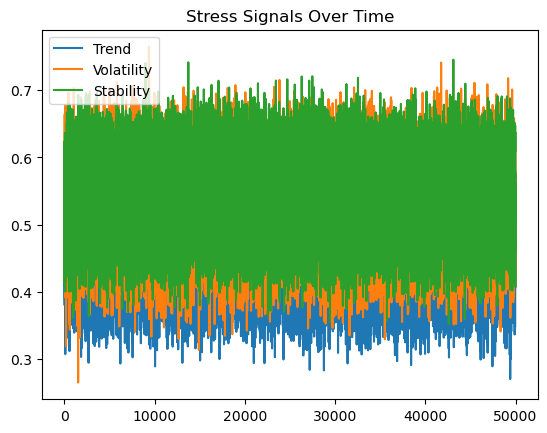

In [23]:
# %%
plt.plot(stress_outputs[:, 0], label="Trend")
plt.plot(stress_outputs[:, 1], label="Volatility")
plt.plot(stress_outputs[:, 2], label="Stability")

plt.legend()
plt.title("Stress Signals Over Time")
plt.show()

In [25]:
load_series = df["Power Consumption (kW)"].values[WINDOW_SIZE:-1]
stress_trend = stress_outputs[:, 0]

print("Load length:", len(load_series))
print("Stress length:", len(stress_trend))

corr = np.corrcoef(load_series, stress_trend)[0, 1]
print("Correlation between Load and Stress Trend:", corr)

Load length: 49969
Stress length: 49969
Correlation between Load and Stress Trend: -0.04562534396151878
